In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path(sys.prefix).parent
%cd {PROJECT_ROOT}

/home/younes/younes/Projects/Python/barid_internship


In [25]:
import polars as pl

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
import calendar
from fpppy.utils import plot_series, plot_series_stacked, plot_diagnostics
from scipy.stats import pearsonr
from plotly import express as px
import altair as alt
from pathlib import Path
import pm4py
from pm4py.objects.conversion.log import converter as log_converter
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.objects.conversion.process_tree import converter as pt_converter
from pm4py.visualization.petri_net import visualizer as pn_visualizer



import importlib
import offline_historique

importlib.reload(offline_historique)
from offline_historique import parse_historique_from_folder  # noqa: E402

cfg = pl.Config()
cfg.set_tbl_width_chars(10000)
cfg.set_fmt_str_lengths(100)
cfg.set_tbl_cols(-1)
cfg.set_tbl_rows(100)

polars.config.Config

In [128]:
def complete_operations(df):
    return df.filter(
        pl.col("status_code").first().over("id") == "depot",
        pl.col("status_code").last().over("id").is_in(["liv", "liv_ret"]),
    )


def complete_operations_pod(df):
    return df.filter(
        pl.col("status_code").first().over("id") == "areturn",
        pl.col("status_code").last().over("id").is_in(["liv", "liv_ret"]),
    )

In [104]:
operations = (
    pl.read_parquet("data/cab_dfs/operations.parquet")
    .filter(is_valid="V")
    .sort(
        pl.col("Heure_Syst_Oper").min().over("id"),
        pl.col("Heure_Syst_Oper"),
    )
)
fields = pl.read_parquet("data/cab_dfs/fields.parquet")

In [105]:
print(fields.group_by("Produit_Niveau_Service").len().sort("len", descending=True))

shape: (14, 2)
┌──────────────────────────────┬───────┐
│ Produit_Niveau_Service       ┆ len   │
│ ---                          ┆ ---   │
│ str                          ┆ u32   │
╞══════════════════════════════╪═══════╡
│ Amana Express 3              ┆ 34621 │
│ Express - PRN                ┆ 33492 │
│ AMANA E-commerce             ┆ 15500 │
│ Amana Express 4              ┆ 13538 │
│ Amana Express 2              ┆ 12099 │
│ Petit Paquet                 ┆ 998   │
│ AMANA PREPAYE                ┆ 285   │
│ AMANA CND                    ┆ 241   │
│ Post Colis Prioritaire       ┆ 198   │
│ Chrono Express International ┆ 38    │
│ Chrono Classic International ┆ 34    │
│ EMS                          ┆ 9     │
│                              ┆ 6     │
│ AMANA spéciale militaire     ┆ 1     │
└──────────────────────────────┴───────┘


In [106]:
print(
    operations.filter(pl.col("status_code").first().over("id") != "depot")
)

shape: (183_557, 13)
┌────────────────┬──────────┬────────────────┬─────────────────────┬─────────────────────┬──────────────────────────────────┬────────────┬────────────────────────┬───────────┬───────────┬───────────┬─────────────┬──────────┐
│ cab            ┆ id       ┆ Date_operation ┆ Heure_Syst_Oper     ┆ Statut              ┆ Agence                           ┆ Agent_oper ┆ Etat                   ┆ Date_Etat ┆ Agent_maj ┆ ORIGINE   ┆ status_code ┆ is_valid │
│ ---            ┆ ---      ┆ ---            ┆ ---                 ┆ ---                 ┆ ---                              ┆ ---        ┆ ---                    ┆ ---       ┆ ---       ┆ ---       ┆ ---         ┆ ---      │
│ str            ┆ str      ┆ date           ┆ datetime[μs]        ┆ str                 ┆ str                              ┆ i64        ┆ str                    ┆ str       ┆ str       ┆ str       ┆ str         ┆ str      │
╞════════════════╪══════════╪════════════════╪═════════════════════╪═══════════

In [ ]:
34_561

In [ ]:
complete_operations = operations
print(complete_operations)

shape: (34_561, 13)
┌───────────────┬──────────┬────────────────┬─────────────────────┬─────────────────────┬────────────────────────────────┬────────────┬────────────────────────┬───────────┬───────────┬───────────┬─────────────┬──────────┐
│ cab           ┆ id       ┆ Date_operation ┆ Heure_Syst_Oper     ┆ Statut              ┆ Agence                         ┆ Agent_oper ┆ Etat                   ┆ Date_Etat ┆ Agent_maj ┆ ORIGINE   ┆ status_code ┆ is_valid │
│ ---           ┆ ---      ┆ ---            ┆ ---                 ┆ ---                 ┆ ---                            ┆ ---        ┆ ---                    ┆ ---       ┆ ---       ┆ ---       ┆ ---         ┆ ---      │
│ str           ┆ str      ┆ date           ┆ datetime[μs]        ┆ str                 ┆ str                            ┆ i64        ┆ str                    ┆ str       ┆ str       ┆ str       ┆ str         ┆ str      │
╞═══════════════╪══════════╪════════════════╪═════════════════════╪═════════════════════╪═══

In [162]:
log = (
    operations.filter(
        pl.col("status_code").first().over("id") == "depot",
        pl.col("status_code").last().over("id").is_in(["liv", "liv_ret"]),
        pl.col("status_code")
        .is_in(
            [
                "lev",
                # "recpt",
                # "aexp",
            ]
        )
        .not_(),
    )
    .rename(
        {
            "id": "case:concept:name",
            "status_code": "concept:name",
            "Heure_Syst_Oper": "time:timestamp",
        }
    )
    .to_pandas()
)

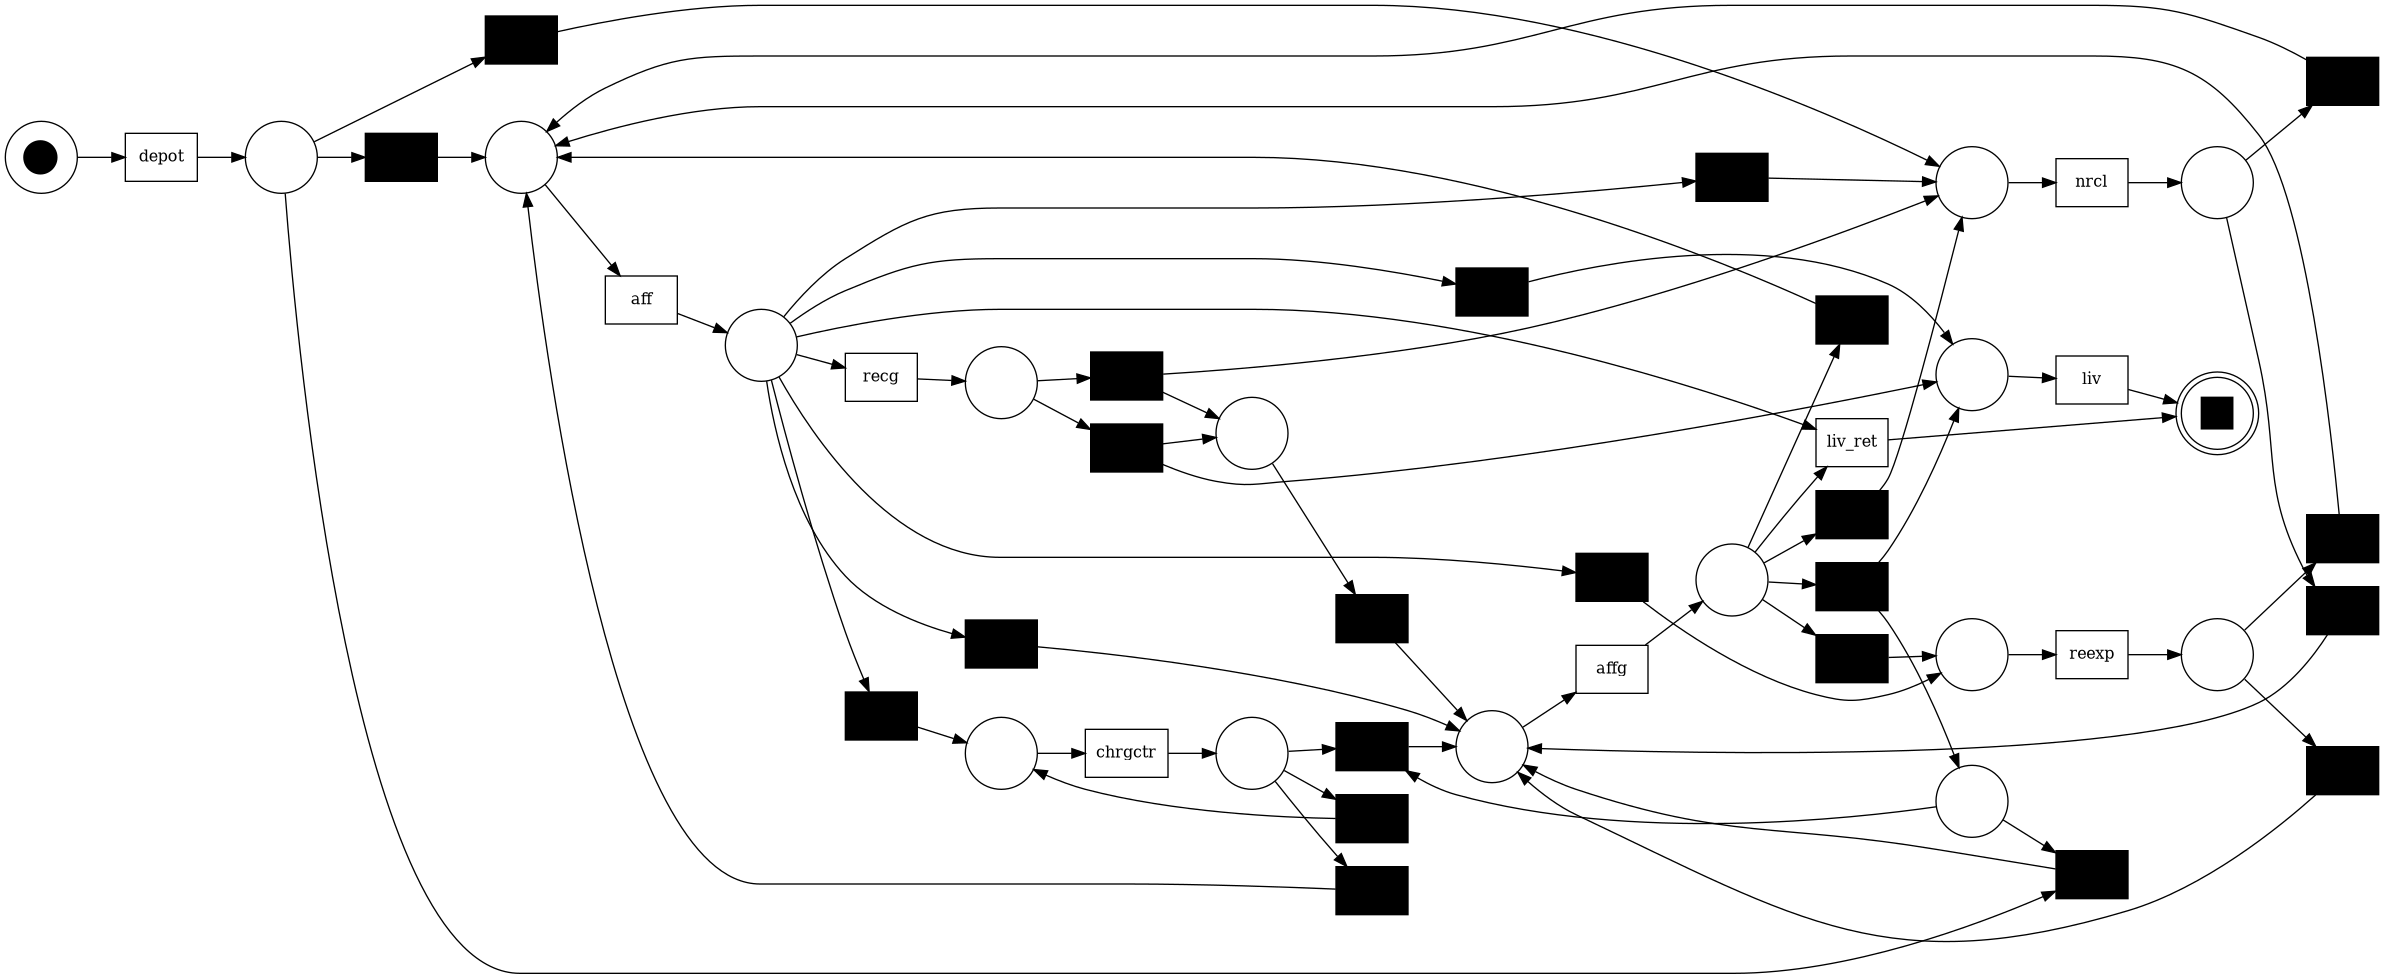

In [144]:
net, initial_marking, final_marking = pm4py.discover_petri_net_heuristics(log)
pm4py.view_petri_net(
    net,
    initial_marking,
    final_marking,
    # format="svg",
)

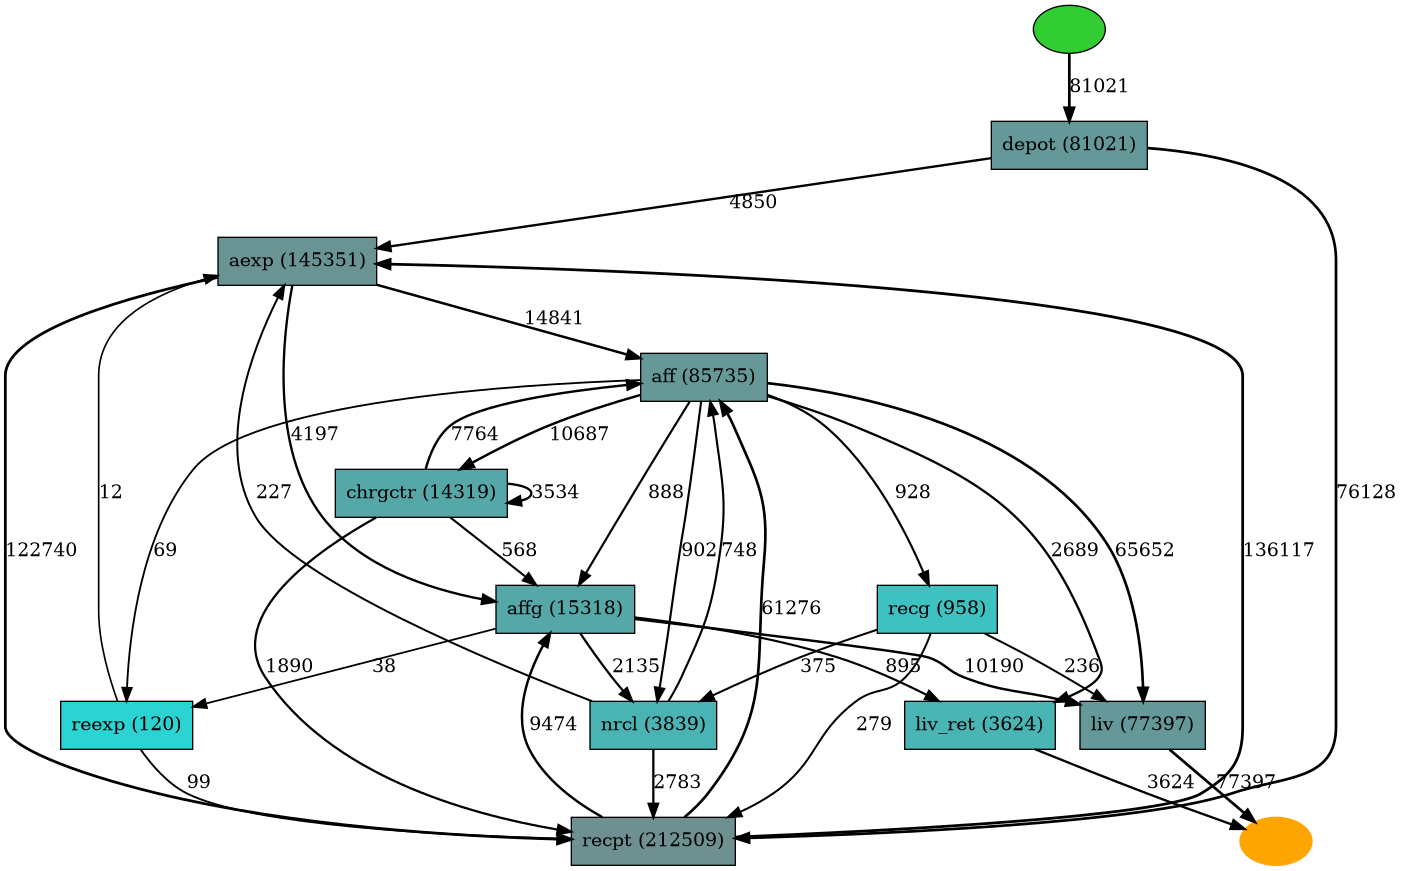

In [163]:
heuristics_net = pm4py.discover_heuristics_net(log)
pm4py.view_heuristics_net(heuristics_net)

In [156]:
heuristics_net.nodes

{'aff': (node:aff connections:{liv:[0.9999850140118989], liv_ret:[0.9996283909327388], recg:[0.7215541165587419], affg:[0], chrgctr:[0], nrcl:[0], reexp:[0]}),
 'liv': (node:liv connections:{}),
 'liv_ret': (node:liv_ret connections:{}),
 'recg': (node:recg connections:{affg:[0.9928057553956835], liv:[0.9957983193277311], nrcl:[0.9975]}),
 'affg': (node:affg connections:{affg:[0.9984779299847792], liv:[0.9999022100528066], liv_ret:[0.9988998899889989], aff:[0], nrcl:[0], reexp:[0]}),
 'chrgctr': (node:chrgctr connections:{affg:[0.9995896594173164], chrgctr:[0.9997172745264349], aff:[0]}),
 'depot': (node:depot connections:{aff:[0.9999859156913283], affg:[0.9998964696138316], nrcl:[0.9940119760479041]}),
 'nrcl': (node:nrcl connections:{aff:[0], affg:[0]}),
 'reexp': (node:reexp connections:{aff:[0], affg:[0]})}

In [ ]:
heuristics_net = pm4py.discover_(log)
pm4py.view_per(heuristics_net)

TypeError: view_performance_spectrum() missing 1 required positional argument: 'activities'